# Dynamic Pricing Optimization - Phase 3: Demand Prediction Models

This notebook trains and compares three regression models to predict weekly demand (sales).

## Phase 3 Goals
1. Load Phase 2 engineered dataset
2. Perform leakage-safe time-based train/test split
3. Train Linear Regression, Random Forest, Gradient Boosting
4. Evaluate MAE, RMSE, R2
5. Select and save the best model
6. Visualize model performance

In [13]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

sys.path.append(os.path.abspath('../src'))

from model_training import (
    load_phase3_data,
    train_three_models,
    evaluate_models,
    get_best_model_name,
    save_phase3_artifacts
)
from feature_engineering import split_scale_for_modeling

print('Phase 3 imports loaded successfully.')

Phase 3 imports loaded successfully.


## 1. Load Data

In [2]:
df = load_phase3_data('../data/walmart_ml_ready.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (6255, 34)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,...,Price_Holiday_Interaction,Price_Unemployment_Interaction,Temperature_Fuel_Interaction,CPI_Unemployment_Interaction,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Holiday_Type_Holiday,Holiday_Type_Non-Holiday
0,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,...,0.0,654.39738,122.06250,1713.204258,0,1,0,0,0,1
1,1,2010-03-12,1439541.59,0,57.79,2.667,211.380643,8.106,2010,3,...,0.0,683.41686,154.12593,1713.451491,0,1,0,0,0,1
2,1,2010-03-19,1472515.79,0,54.58,2.720,211.215635,8.106,2010,3,...,0.0,629.10666,148.45760,1712.113937,0,1,0,0,0,1
3,1,2010-03-26,1404429.92,0,51.45,2.732,211.018042,8.106,2010,3,...,0.0,629.43090,140.56140,1710.512252,0,1,0,0,0,1
4,1,2010-04-02,1594968.28,0,62.27,2.719,210.820450,7.808,2010,4,...,0.0,661.49376,169.31213,1646.086073,0,1,0,0,0,1


In [3]:
print('Columns in Phase 3 dataset:')
for i, c in enumerate(df.columns, 1):
    print(f'{i:2}. {c}')

Columns in Phase 3 dataset:
 1. Store
 2. Date
 3. Weekly_Sales
 4. Holiday_Flag
 5. Temperature
 6. Fuel_Price
 7. CPI
 8. Unemployment
 9. Year
10. Month
11. Week
12. Quarter
13. Sales_Lag_1
14. Sales_Lag_2
15. Sales_Rolling_Mean_4
16. Sales_Rolling_Std_4
17. Season_Price_Factor
18. Price
19. Month_sin
20. Month_cos
21. Week_sin
22. Week_cos
23. Quarter_sin
24. Quarter_cos
25. Price_Holiday_Interaction
26. Price_Unemployment_Interaction
27. Temperature_Fuel_Interaction
28. CPI_Unemployment_Interaction
29. Season_Fall
30. Season_Spring
31. Season_Summer
32. Season_Winter
33. Holiday_Type_Holiday
34. Holiday_Type_Non-Holiday


## 2. Leakage-Safe Split and Scaling

In [4]:
X_train, X_test, y_train, y_test, scaler, scaled_cols = split_scale_for_modeling(
    df,
    target_col='Weekly_Sales',
    date_col='Date',
    test_size=0.2
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print(f'Scaled feature columns: {len(scaled_cols)}')

Train shape: (5004, 32)
Test shape: (1251, 32)
Scaled feature columns: 32


## 3. Train Models

In [5]:
models = train_three_models(X_train, y_train, random_state=42)
print('Models trained:')
print(list(models.keys()))

Models trained:
['LinearRegression', 'RandomForest', 'GradientBoosting']


## 4. Evaluate Models

In [6]:
metrics_df, predictions = evaluate_models(models, X_test, y_test)
metrics_df

,Model,MAE,RMSE,R2
0,GradientBoosting,41302.145290,60344.294525,0.987171
1,RandomForest,46553.040178,65450.938196,0.984908
2,LinearRegression,58593.255994,78695.784224,0.978182


In [7]:
best_model_name = get_best_model_name(metrics_df)
print(f'Best model (by RMSE): {best_model_name}')

Best model (by RMSE): GradientBoosting


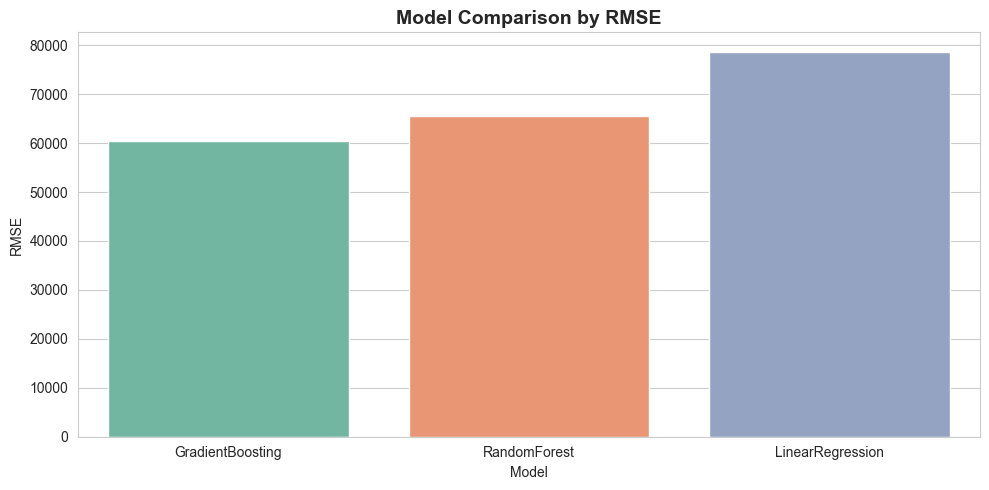

Saved: ../output/phase3_model_rmse_comparison.png


In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='RMSE', hue='Model', legend=False, palette='Set2')
plt.title('Model Comparison by RMSE', fontsize=14, fontweight='bold')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.tight_layout()
plt.savefig('../output/phase3_model_rmse_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../output/phase3_model_rmse_comparison.png')

## 5. Prediction Diagnostics

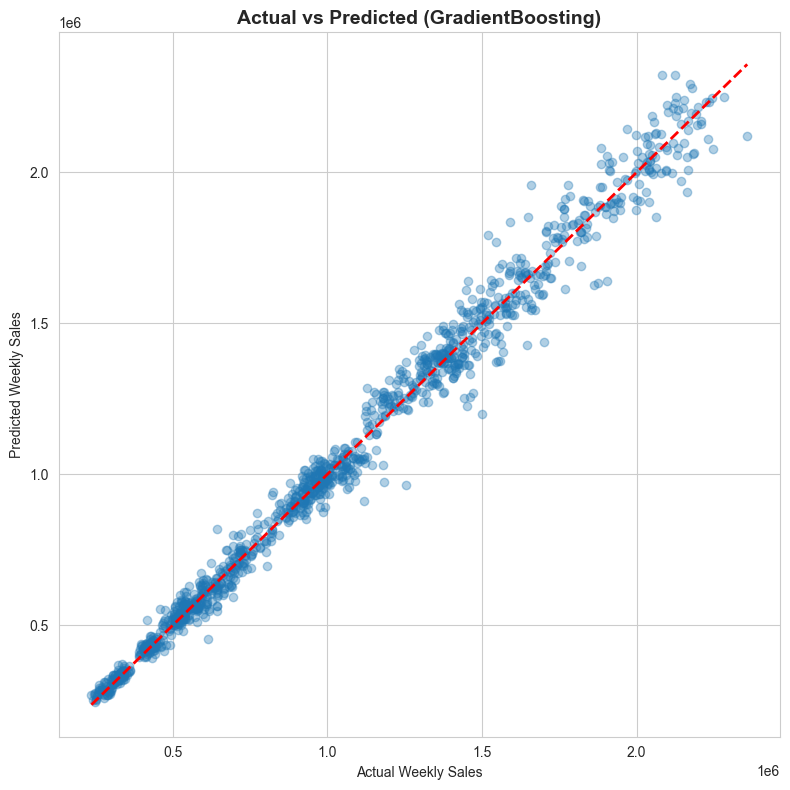

Saved: ../output/phase3_actual_vs_predicted.png


In [9]:
y_pred_best = predictions[best_model_name]

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.35)
mn = min(y_test.min(), y_pred_best.min())
mx = max(y_test.max(), y_pred_best.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2)
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title(f'Actual vs Predicted ({best_model_name})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/phase3_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../output/phase3_actual_vs_predicted.png')

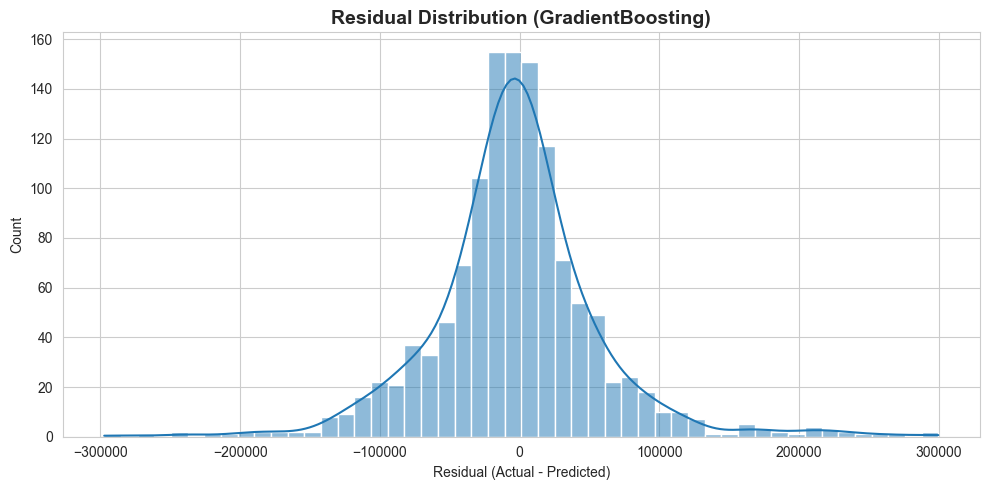

Saved: ../output/phase3_residual_distribution.png


In [10]:
errors = y_test - y_pred_best

plt.figure(figsize=(10, 5))
sns.histplot(errors, bins=50, kde=True)
plt.title(f'Residual Distribution ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.savefig('../output/phase3_residual_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ../output/phase3_residual_distribution.png')

## 6. Save Best Model and Metrics

In [11]:
artifacts = save_phase3_artifacts(
    metrics_df=metrics_df,
    models=models,
    best_model_name=best_model_name,
    scaler=scaler,
    feature_columns=list(X_train.columns),
    out_models_dir='../models',
    out_output_dir='../output',
)

print('Phase 3 artifacts saved:')
for k, v in artifacts.items():
    print(f'- {k}: {v}')

Phase 3 artifacts saved:
- metrics_csv: ../output\phase3_model_metrics.csv
- best_model_file: ../models\best_demand_model.joblib
- scaler_file: ../models\phase3_scaler.joblib
- metadata_file: ../models\phase3_metadata.json


## Phase 3 Summary

- Trained and compared Linear Regression, Random Forest, and Gradient Boosting
- Evaluated with MAE, RMSE, R2 on a time-based holdout set
- Saved best-performing model and preprocessing artifacts

Next: Phase 4 Price Elasticity Analysis